In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
import pandas as pd

data = pd.read_csv("/home/TE/Downloads/31116/9_dsbda/Social_Network_Ads(1).csv")

In [2]:
data['Gender'] = data['Gender'].map({'Male':0,'Female':1})

In [3]:
X = np.asarray(data.drop(["Purchased"], axis=1))
Y = np.asarray(data["Purchased"])

x = data.drop(["Purchased"], axis=1)
y = data["Purchased"]

print(f"X type: {type(X)}")

X type: <class 'numpy.ndarray'>


In [4]:
x_train,x_test , y_train,y_test = train_test_split(X,Y,random_state=42)

In [5]:
data

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,0,19,19000,0
1,15810944,0,35,20000,0
2,15668575,1,26,43000,0
3,15603246,1,27,57000,0
4,15804002,0,19,76000,0
...,...,...,...,...,...
395,15691863,1,46,41000,1
396,15706071,0,51,23000,1
397,15654296,1,50,20000,1
398,15755018,0,36,33000,0


In [6]:
nb = GaussianNB()


model = nb.fit(x_train,y_train)

In [7]:
y_pred = model.predict(x_test)

In [8]:
from sklearn.metrics import confusion_matrix,f1_score,recall_score,precision_score,accuracy_score


def print_cf(y_test,y_pred):
    print(f"Confusion matrix: \n{confusion_matrix(y_test,y_pred)}")
    return confusion_matrix(y_test,y_pred)


def print_acccuracy(y_test,y_pred):
    print(f"Accuracy score:{accuracy_score(y_test,y_pred)}")
    return accuracy_score(y_test,y_pred)


def print_precision(y_test,y_pred):
    print(f"Precision score:{precision_score(y_test,y_pred)}")
    return precision_score(y_test,y_pred)

def print_recall(y_test,y_pred):
    print(f"Recall score:{recall_score(y_test,y_pred)}")
    return recall_score(y_test,y_pred)


def print_f1(y_test,y_pred):
    print(f"F1 score:{f1_score(y_test,y_pred)}")
    return f1_score(y_test,y_pred)



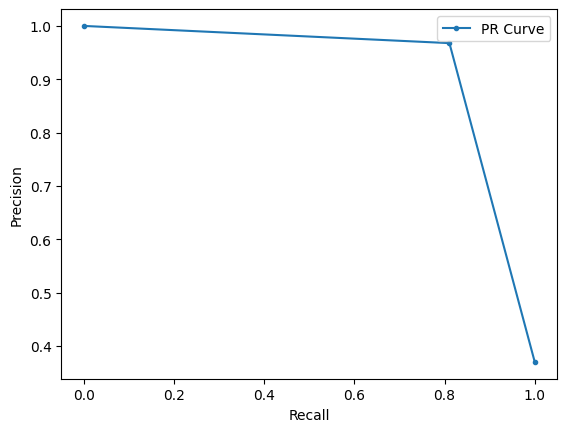

In [9]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
plt.plot(recall, precision, marker='.', label='PR Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

In [10]:
print_cf(y_test,y_pred)
print("\n")

accuracy:float = print_acccuracy(y_test,y_pred)
print("\n")

print_precision(y_test,y_pred)
print("\n")

print_recall(y_test,y_pred)
print("\n")

print_f1(y_test,y_pred)
print(f"\nError: {1-accuracy}")

Confusion matrix: 
[[62  1]
 [ 7 30]]


Accuracy score:0.92


Precision score:0.967741935483871


Recall score:0.8108108108108109


F1 score:0.8823529411764706

Error: 0.07999999999999996


In [11]:
tn = ((y_pred == 0) & (y_test == 0)).sum()
fp = ((y_pred == 1) & (y_test == 0)).sum()
tp = ((y_pred == 1) & (y_test == 1)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()

In [12]:
recall = tp/(tp + fn)
accuracy = (tp + tn)/(tp + fp + tn + fn)
precision = tp / (tp + fp)
error = 1 - accuracy
f1 = (2 * recall * precision)/(recall + precision)


In [13]:
print(f"Recall: {recall}")
print(f"Precision:  {precision}")
print(f"Accuracy:  {accuracy}")
print(f"F1 Score: {f1} ")

Recall: 0.8108108108108109
Precision:  0.967741935483871
Accuracy:  0.92
F1 Score: 0.8823529411764706 
